In [4]:
# Initial setup for cleaning song titles
import re
from nltk.corpus import stopwords
from collections import Counter
import nltk

nltk.download('stopwords')
stopwords_set = set(stopwords.words('english'))

def clean_title(title):
    title = title.lower()
    title = re.sub(r'[^a-z0-9\s]', '', title)  # Remove punctuation
    tokens = title.split()
    tokens = [t for t in tokens if t not in stopwords_set]
    return ' '.join(tokens)

[nltk_data] Downloading package stopwords to C:\Users\Riley
[nltk_data]     Willis\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
import sqlite3
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity


conn = sqlite3.connect('dbs/playlists.db')
df_titles = pd.read_sql_query("SELECT pid, name FROM playlists", conn)
conn.close()

df_titles["tokens"] = df_titles["name"].fillna("").apply(clean_title)

# Create TF-IDF matrix
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df_titles["tokens"])


In [6]:
# We'll only care about the top N playlist genres/themes.
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

top_n = 100 # Number of top themes to consider

term_frequencies = np.asarray(tfidf_matrix.sum(axis=0)).flatten()
top_indices = np.argsort(-term_frequencies)[:top_n]
top_terms = vectorizer.get_feature_names_out()[top_indices]

binary_matrix = (tfidf_matrix[:, top_indices] > 0).astype(int)

playlist_theme_df = pd.DataFrame.sparse.from_spmatrix(binary_matrix, columns=top_terms, index=df_titles["pid"])

In [7]:
# Calculating staple scores *Note: I understand most of this code, but some of it was optimized for performance with an AI assistant
import numpy as np
import scipy.sparse as sp

def calc_staple_scores(theme_df, tracks_df):
    pid_to_index = {pid: idx for idx, pid in enumerate(theme_df.index)} # mapping playlist ID to row index
    theme_matrix = sp.csr_matrix(theme_df.sparse.to_coo().astype(int)) # converting to SPARSE matrix, as playlists will likely have 1 or few themes

    unique_tracks = tracks_df['track_uri'].unique()
    track_to_index = {track: idx for idx, track in enumerate(unique_tracks)} # mapping track URI to column index

    #playlist -> song sparse matrix
    row_indices = tracks_df['pid'].map(pid_to_index).values # from each track-row, map to its playlist index it belongs to
    col_indices = tracks_df['track_uri'].map(track_to_index).values # from each track-row, map to its song index it is

    data = np.ones(len(tracks_df), dtype=int) # creating binary matrix; 1s mean song is in playlist, 0s mean it is not
    playlist_song_matrix = sp.csr_matrix((data, (row_indices, col_indices)), shape=(len(pid_to_index), len(track_to_index))) # sparse matrix of which songs are in which playlists

    theme_song_counts = theme_matrix.T @ playlist_song_matrix # themes (dot product) songs = for each theme, how many playlists with that theme have each song
    playlists_per_theme = theme_matrix.sum(axis=0).A1 # Count how many playlists have each theme
    playlists_per_theme[playlists_per_theme == 0] = 1  # Avoid division by zero

    D_inv = sp.diags(1 / playlists_per_theme)  # Create a diagonal matrix for normalization
    staple_scores = D_inv.dot(theme_song_counts)  # Normalized; dot-product of the inverse is equivalent to divide total playlists for that theme to get fraction staple-score

    staple_scores_transposed = staple_scores.T

    song_theme_staple_df = pd.DataFrame(
        staple_scores_transposed.toarray(),
        index=unique_tracks,
        columns=playlist_theme_df.columns)
    
    return song_theme_staple_df

In [8]:
# getting tracks from database
import sqlite3
import pandas as pd

conn = sqlite3.connect('dbs/playlists.db')
tracks_df = pd.read_sql_query("SELECT pid, track_uri FROM playlist_track", conn)
conn.close()


In [9]:
# Calculate staple scores using the playlist themes found earlier
staple_scores_df = calc_staple_scores(playlist_theme_df, tracks_df)

In [45]:
#staple_scores_df.to_csv('staple_scores.csv')
staple_scores_df.to_pickle('staple_scores.pkl') # Pickle is much faster, but not human-readable

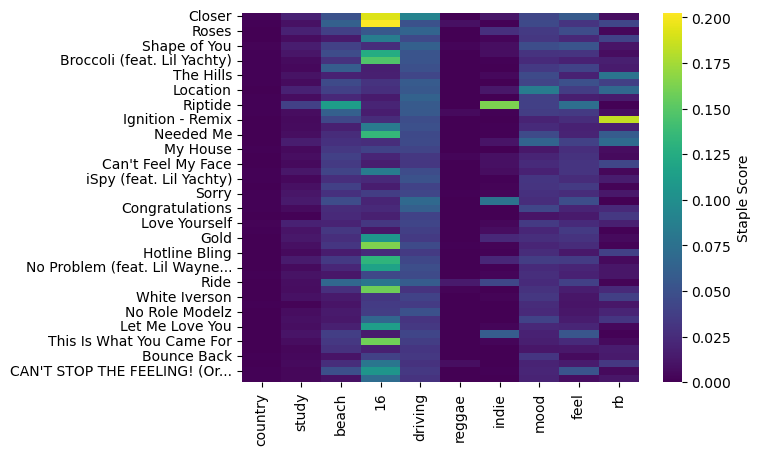

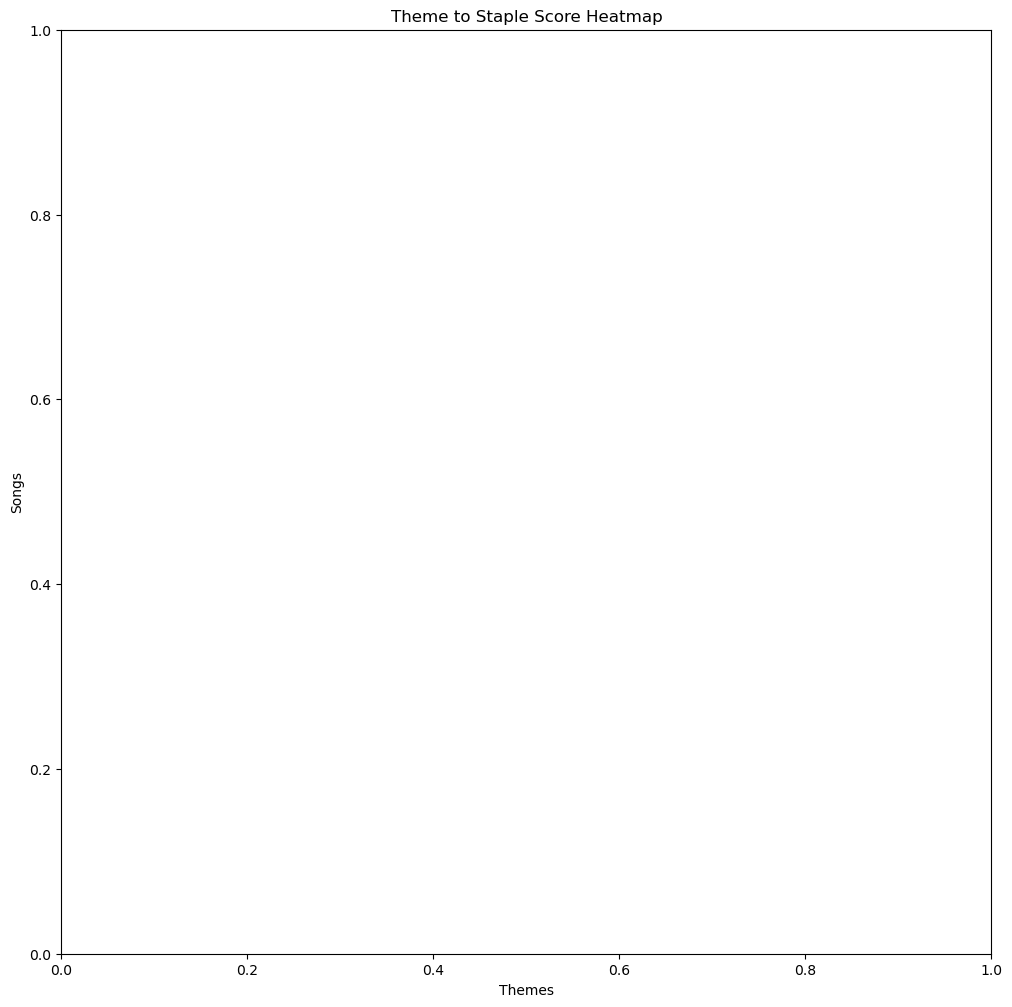

In [ ]:
# Visualization of top 50 songs and top 10 themes. I am struggling to get the track URI to map to track names, so I will just use the URI for now.
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3

def truncate_label(label, max_length=30):
    return label if len(label) <= max_length else label[:max_length-3] + '...'

top_songs = staple_scores_df.median(axis=1).sort_values(ascending=False).head(50).index
top_themes = staple_scores_df.median(axis=0).sort_values(ascending=False).head(10).index

conn = sqlite3.connect('dbs/song_features.db')
song_df = pd.read_sql_query("SELECT track_uri, track_name from song_features", conn)
conn.close()

uri_to_name = dict(zip(song_df['track_uri'], song_df['track_name']))

subset = staple_scores_df.loc[top_songs, top_themes]
subset_named = subset.copy()
subset_named.index = subset_named.index.map(lambda x: truncate_label(uri_to_name.get(x, x)))

plt.figure(figsize=(12, 12))
ax = sns.heatmap(subset_named, cmap='viridis')
colorbar = ax.collections[0].colorbar
colorbar.set_label('Staple Score')
plt.xlabel('Themes')
plt.ylabel('Songs')
plt.title('Theme to Staple Score Heatmap')
plt.show()

In [46]:
#output top 10 results from .pkl file

import pandas as pd

file_path = 'dbs/staple_scores.pkl'

df = pd.read_pickle(file_path)

print(df.head(10))  # Display the top 10 staple scores

                                       country     music     chill    summer  \
spotify:track:0UaMYEvWZi0ZqiDOoHU3YI  0.000045  0.004082  0.000249  0.002491   
spotify:track:0WqIKmW4BTrj3eJFmnCKMv  0.000134  0.012698  0.001442  0.009732   
spotify:track:0XUfyU2QviPAs6bxSpXYG4  0.000445  0.021353  0.002734  0.010516   
spotify:track:0uqPG793dkDDN7sCUJJIVC  0.000134  0.007370  0.007109  0.006411   
spotify:track:12qZHAeOyTf93YAWvGDTat  0.000267  0.016818  0.008154  0.012961   
spotify:track:19Js5ypV6JKn4DMExHQbGc  0.000045  0.002532  0.001491  0.002214   
spotify:track:1AWQoqb9bSvzTjaLralEkT  0.000134  0.007559  0.002536  0.005396   
spotify:track:1Bv0Yl01xBDZD4OQP93fyl  0.000000  0.002608  0.001392  0.000092   
spotify:track:1HwpWwa6bnqqRhK8agG4RS  0.001069  0.006047  0.005071  0.005996   
spotify:track:1JURww012QnWAw0zZXi6Aa  0.000089  0.001927  0.000845  0.002398   

                                          rock     songs       rap     party  \
spotify:track:0UaMYEvWZi0ZqiDOoHU3YI  0